## Genes pronóstico en el microambiente tumoral de glioma de bajo grado

En este cuaderno se procede con la metodología propuesta en el artículo https://pubmed.ncbi.nlm.nih.gov/32309356, adaptada a un flujo de trabajo completo con Python. 

Los datos analizados fueron obtenidos del sitio https://www.linkedomics.org/data_download/TCGA-LGG.

Datos de expresión génica obtenidos por secuenciación masiva de ARN mediante la plataforma Illumina HiSeq. Son datos agegados o resumidos para cada gen, no para isoformas o transcritos específicos. Valores de expresión transcriptómica calculados con RSEM y transformados con logaritmo en base 2 para estabilizar varianza, sumado 1 para evitar log(O). Contiene 516 muestras tumorales de LGG (Lower Grade Glioma) y 20086 genes.

Los datos clínicos se refieren al género del paciente, edad al diagnóstico, etnia y raza, supervivenci global en días, estado (vivo o fallecido), tipo histológico (astrocytoma, oligodendroglioma, oligoastrocytoma) e información sobre radioterapia.

## Carga de los datos

In [2]:
# importacion de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
from sksurv.metrics import concordance_index_censored
from sklearn.linear_model import LogisticRegression

In [3]:
path_clinico = '../data/Human__TCGA_LGG__MS__Clinical__Clinical__01_28_2016__BI__Clinical__Firehose.tsi.txt'
path_genes = '../data/Human__TCGA_LGG__UNC__RNAseq__HiSeq_RNA__01_28_2016__BI__Gene__Firehose_RSEM_log2.cct'

clin = pd.read_csv(path_clinico, sep='\t', index_col=0)
expr = pd.read_csv(path_genes, sep='\t', index_col=0)

print(f"Dimensión datos expresión: {expr.shape}")  # espera genes x muestras
print(f"Dimensión datos clínicos: {clin.shape}")


Dimensión datos expresión: (20086, 516)
Dimensión datos clínicos: (10, 515)


In [4]:
clin.head()

,TCGA.CS.6665,TCGA.CS.6670,TCGA.DB.A4XC,TCGA.DH.5141,TCGA.DH.A66B,TCGA.DU.7300,TCGA.DU.A76O,TCGA.E1.A7YN,TCGA.FG.8187,TCGA.FG.A60K,...,TCGA.VW.A8FI,TCGA.W9.A837,TCGA.WH.A86K,TCGA.WY.A858,TCGA.WY.A859,TCGA.WY.A85A,TCGA.WY.A85B,TCGA.WY.A85C,TCGA.WY.A85D,TCGA.WY.A85E
attrib_name,,,,,,,,,,,,,,,,,,,,,
years_to_birth,51,43,26,32,52,53,30,63,31,34,...,66,NaN,65,32,34,20,24,36,60,48
Tumor_purity,0.6573,0.9816,0.8892,0.9387,0.8806,0.9302,0.836,0.5498,0.9313,0.9553,...,0.8816,0.9888,0.9243,0.7115,0.9966,0.9432,0.836,0.9311,0.9167,0.973
histological_type,astrocytoma,oligodendroglioma,oligoastrocytoma,oligodendroglioma,astrocytoma,oligodendroglioma,astrocytoma,astrocytoma,oligoastrocytoma,oligoastrocytoma,...,astrocytoma,oligodendroglioma,astrocytoma,astrocytoma,astrocytoma,astrocytoma,astrocytoma,astrocytoma,oligoastrocytoma,oligoastrocytoma
gender,female,male,male,male,male,female,male,female,male,female,...,male,male,male,female,female,male,male,male,male,female
radiation_therapy,yes,NaN,yes,yes,yes,no,yes,yes,no,no,...,yes,no,no,yes,yes,no,no,yes,no,no


In [5]:
expr.head()

,TCGA.CS.4938,TCGA.CS.4941,TCGA.CS.4942,TCGA.CS.4943,TCGA.CS.4944,TCGA.CS.5390,TCGA.CS.5393,TCGA.CS.5394,TCGA.CS.5395,TCGA.CS.5396,...,TCGA.VW.A8FI,TCGA.W9.A837,TCGA.WH.A86K,TCGA.WY.A858,TCGA.WY.A859,TCGA.WY.A85A,TCGA.WY.A85B,TCGA.WY.A85C,TCGA.WY.A85D,TCGA.WY.A85E
attrib_name,,,,,,,,,,,,,,,,,,,,,
A1BG,6.5715,6.1944,6.2375,4.9535,4.6844,6.4341,5.5662,5.2841,4.3587,6.5179,...,7.2362,4.7140,8.4603,7.7583,6.1011,6.3097,6.4383,6.9881,8.2396,7.0297
A1CF,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4944,0.0000,0.0000
A2BP1,4.5641,9.0375,8.5295,5.5235,6.7335,8.2774,8.3424,4.3743,8.2314,3.5902,...,4.7021,10.2611,6.0157,2.6741,11.2508,7.4914,5.4604,5.5221,4.7356,9.3438
A2LD1,3.8564,7.1808,5.7117,3.9052,4.2491,4.3597,4.9114,3.1034,7.6662,4.2153,...,6.5365,4.6135,5.2138,5.3648,4.5050,4.8743,4.9876,4.5847,3.9758,3.7495
A2ML1,7.1997,9.0290,7.4545,7.4920,7.3253,6.2381,7.3717,6.0127,9.8985,4.0029,...,6.1683,7.9353,8.9790,5.5743,7.8376,8.3211,5.3276,5.1757,8.0754,7.4474


Los datos originalmente se encuentran organizados en genes o características clínicas por fila y muestras por columnas.

Los datos de expresión génica están normalizados, al ser el objeto de estudio de la primera parte de la investigación no será necesario realizar un preprocesamiento.

## Cálculo de puntajes de microambientes

Mediante el algoritmo ESTIMATE (Estimation of STromal and Immune cells in MAlignant Tumor tissues using Expression data) se calcula: 
- Inmune Score: estimación de la infiltración de células inmunes en la muestra.
- Stromal Score: estimación de la presencia de células estromales.
- ESTIMATE Score: combinación que estima la pureza tumoral (negativamente correlacionada con las anteriores)

Los score se basan en el promedio de la expresión de genes característicos.

$$
\text{Score}_\text{immune} = \sum_{i \in G_{immune}} \text{Exp}_i
$$

$$
\text{Score}_\text{stromal} = \sum_{j \in G_{stromal}} \text{Exp}_j
$$

$$
S_{ESTIMATE} = S_{Immune} + S_{Stromal}
$$


donde $\text{Exp}_i$ es la expresión normalizada del gen marcador $i$.

In [6]:
# listas para immune y stromal generadas 
immune_genes = [
    "ACAP1", "ADAM28", "ADGRE3", "ATM", "BST2", "CD247", "CD27", "CD2", "CD3D", "CD3E",
    "CD3G", "CD52", "CD53", "CD6", "CD7", "CD8A", "CD8B", "CLEC4A", "CLEC7A", "CXCL9",
    "CXCR3", "CYBB", "DOCK2", "FCER1G", "FGR", "FOXP3", "GBP1", "GBP2", "GBP4", "GBP5",
    "GZMA", "GZMB", "HLA-DMA", "HLA-DMB", "HLA-DOA", "HLA-DOB", "HLA-DPA1", "HLA-DPB1",
    "HLA-DQA1", "HLA-DQA2", "HLA-DQB1", "HLA-DQB2", "HLA-DRA", "HLA-DRB1", "HLA-DRB5",
    "IFI16", "IFIH1", "IFIT3", "IL10RA", "IL2RA", "IRF8", "LAPTM5", "LAIR1", "LCP2", "LILRB2",
    "LILRB4", "LYN", "MS4A1", "MPEG1", "MX1", "NCKAP1L", "NLRC4", "NOD2", "NRP1", "P2RY12",
    "PTPRC", "PTPN7", "PTPN22", "SASH3", "SIRPA", "SLA", "SLAMF6", "SPI1", "STAT1", "STAT4",
    "SYK", "TBX21", "TLR1", "TLR3", "TLR6", "TLR7", "TREM2", "TRIM21", "TRIM68", "TYROBP",
    "WAS", "ZAP70", "CLEC12A", "S1PR4", "SPN", "CXCL10", "CXCL11", "CCL4", "CCL5", "CCR5",
    "CCR7", "CD40LG", "ITGAL", "PACSIN1", "SH2D1A", "PRKCB", "TAP1", "TAP2", "TAPBP",
    "TRIM25", "CD274", "PDCD1", "CTLA4", "TIGIT", "ICOS", "FOXP3", "IL7R", "GZMK", "NAT2",
    "HLA-A", "HLA-B", "HLA-C", "IFIT3"
]

stromal_genes = [
    "ABI3", "ACVRL1", "ADAM12", "ADAMTS12", "AEBP1", "AGRN", "ANGPT1", "ANTXR1",
    "AQP1", "ASPN", "BGN", "BMP4", "CDH11", "COL1A1", "COL1A2", "COL3A1", "COL5A1",
    "COL5A2", "COL6A1", "COL6A2", "COL6A3", "COL8A1", "COL8A2", "COMP", "CRTAC1",
    "DDIT4", "DCN", "DPT", "ELN", "ENG", "FAP", "FBN1", "FBLN2", "FBN3", "FCN3", "FGF7",
    "FHL2", "FLI1", "FN1", "FOXC1", "GJA4", "GJA5", "GLT8D2", "GREM1", "HAPLN1",
    "HAS2", "HGF", "HLF", "ICAM1", "IGFBP5", "ITGA11", "ITGA8", "ITGAX", "ITGB8",
    "JAM2", "KCNJ8", "KDR", "LAMA1", "LAMA2", "LAMA4", "LAMB1", "LAMC1", "LMO2",
    "MMP2", "MMP3", "MMP11", "MMP14", "MMP16", "MMP9", "MXRA5", "MYH11",
    "NID2", "PDGFA", "PDGFRA", "PDGFRB", "PECAM1", "PLOD1", "POSTN", "PTGS2",
    "RGS5", "RSPO3", "SCRG1", "SEMA3A", "SERPINE1", "SIGLEC1", "SLC2A3", "SLIT2",
    "SMOC2", "SPON1", "SPARC", "SPP1", "STC1", "TCF21", "TGFB3", "TIMP1", "TNC",
    "TNXB", "TPM1", "TPM2", "VCAN", "VWF", "WISP1", "XDH", "ZEB1", "ZNF423"
]

In [7]:
# filtrado de genes presentes en el dataset
immune_genes_present = [g for g in immune_genes if g in expr.index]
stromal_genes_present = [g for g in stromal_genes if g in expr.index]

print(f"Immune genes usados: {len(immune_genes_present)}")
print(f"Stromal genes usados: {len(stromal_genes_present)}")

# Calcular scores: promedio expresión de genes de cada set para cada muestra
immune_score = expr.loc[immune_genes_present].mean(axis=0)
stromal_score = expr.loc[stromal_genes_present].mean(axis=0)

# Score ESTIMATE, suma de scores
estimate_score = immune_score + stromal_score

# Unión en un DataFrame para análisis posterior
scores_df = pd.DataFrame({
    'immune_score': immune_score,
    'stromal_score': stromal_score,
    'estimate_score': estimate_score
})

scores_df.head()

Immune genes usados: 117
Stromal genes usados: 105


,immune_score,stromal_score,estimate_score
TCGA.CS.4938,5.967111,7.132758,13.099869
TCGA.CS.4941,8.132838,8.345325,16.478163
TCGA.CS.4942,7.464896,7.209186,14.674081
TCGA.CS.4943,6.138782,7.550289,13.689071
TCGA.CS.4944,6.482274,7.448770,13.931043


In [8]:
scores_df

,immune_score,stromal_score,estimate_score
TCGA.CS.4938,5.967111,7.132758,13.099869
TCGA.CS.4941,8.132838,8.345325,16.478163
TCGA.CS.4942,7.464896,7.209186,14.674081
TCGA.CS.4943,6.138782,7.550289,13.689071
TCGA.CS.4944,6.482274,7.448770,13.931043
...,...,...,...
TCGA.WY.A85A,6.099294,7.205918,13.305212
TCGA.WY.A85B,6.656585,7.292004,13.948588
TCGA.WY.A85C,6.109927,7.688792,13.798720
TCGA.WY.A85D,5.961627,6.944327,12.905954


## Preprocesamiento de dataset de variables clínicas

Es necesario modificar los tipos de datos a tipos adecuados para el trabajo como valores numéricos y el establecimiento de variables categoriales. La limpieza de los datos y eliminación de columnas innecesarias (la supervivencia está repetida)

In [9]:
clin = clin.T
clin.head()

attrib_name,years_to_birth,Tumor_purity,histological_type,gender,radiation_therapy,race,ethnicity,overall_survival,status,overallsurvival
TCGA.CS.6665,51,0.6573,astrocytoma,female,yes,white,nothispanicorlatino,1568,0,"1568,0"
TCGA.CS.6670,43,0.9816,oligodendroglioma,male,NaN,white,nothispanicorlatino,1426,0,"1426,0"
TCGA.DB.A4XC,26,0.8892,oligoastrocytoma,male,yes,white,nothispanicorlatino,1421,0,"1421,0"
TCGA.DH.5141,32,0.9387,oligodendroglioma,male,yes,white,hispanicorlatino,968,0,"968,0"
TCGA.DH.A66B,52,0.8806,astrocytoma,male,yes,white,nothispanicorlatino,1279,0,"1279,0"


In [10]:
clin.info()

<class 'pandas.core.frame.DataFrame'>
Index: 515 entries, TCGA.CS.6665 to TCGA.WY.A85E
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   years_to_birth     514 non-null    object
 1   Tumor_purity       515 non-null    object
 2   histological_type  515 non-null    object
 3   gender             515 non-null    object
 4   radiation_therapy  482 non-null    object
 5   race               505 non-null    object
 6   ethnicity          481 non-null    object
 7   overall_survival   481 non-null    object
 8   status             481 non-null    object
 9   overallsurvival    515 non-null    object
dtypes: object(10)
memory usage: 60.4+ KB


In [11]:
clin['overall_survival'] = pd.to_numeric(clin['overall_survival'], errors='coerce') # pasar días a numérico
clin = clin.drop(columns=['overallsurvival']) # eliminar por redundante

clin['years_to_birth'] = pd.to_numeric(clin['years_to_birth'], errors='coerce') # a numérico la edad

clin['Tumor_purity'] = pd.to_numeric(clin['Tumor_purity'], errors='coerce') # a float 

# categoriales
categorical_cols = ['histological_type', 'gender', 'radiation_therapy', 'race', 'ethnicity', 'status']
for col in categorical_cols:
    # Tomar valores no nulos y convertirlos a categorías
    clin[col] = clin[col].astype('category')

In [12]:
print(clin['status'].value_counts())

status
0    358
1    123
Name: count, dtype: int64


In [13]:
clin['status'] = pd.to_numeric(clin['status'], errors='coerce') # llevar status a numérico
clin['status'] = clin['status'].astype(bool)

In [14]:
print(clin.isna().sum())

attrib_name
years_to_birth        1
Tumor_purity          0
histological_type     0
gender                0
radiation_therapy    33
race                 10
ethnicity            34
overall_survival     34
status                0
dtype: int64


In [15]:
clin = clin.dropna(subset=['overall_survival', 'status']) # eliminamos aquellos que no tengamos supervivencia y estado

In [16]:
clin.info()

<class 'pandas.core.frame.DataFrame'>
Index: 481 entries, TCGA.CS.6665 to TCGA.WY.A85E
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   years_to_birth     480 non-null    float64 
 1   Tumor_purity       481 non-null    float64 
 2   histological_type  481 non-null    category
 3   gender             481 non-null    category
 4   radiation_therapy  465 non-null    category
 5   race               472 non-null    category
 6   ethnicity          450 non-null    category
 7   overall_survival   481 non-null    float64 
 8   status             481 non-null    bool    
dtypes: bool(1), category(5), float64(3)
memory usage: 18.5+ KB


In [17]:
clin.head()

attrib_name,years_to_birth,Tumor_purity,histological_type,gender,radiation_therapy,race,ethnicity,overall_survival,status
TCGA.CS.6665,51.0,0.6573,astrocytoma,female,yes,white,nothispanicorlatino,1568.0,False
TCGA.CS.6670,43.0,0.9816,oligodendroglioma,male,NaN,white,nothispanicorlatino,1426.0,False
TCGA.DB.A4XC,26.0,0.8892,oligoastrocytoma,male,yes,white,nothispanicorlatino,1421.0,False
TCGA.DH.5141,32.0,0.9387,oligodendroglioma,male,yes,white,hispanicorlatino,968.0,False
TCGA.DH.A66B,52.0,0.8806,astrocytoma,male,yes,white,nothispanicorlatino,1279.0,False


## Análisis estadístico de puntajes y supervivencia 

Se comparan los puntajes con variables clínicas mediante pruebas como t-test y ANOVA. Con los pacientes agrupados por alto o bajo puntaje según la mediana se realizan análisis de supervivencia a través de curvas Kaplan-Meier (probabilidad de supervivencia) y Test log-rank (comparar diferencias entre grupos).

Mediante boxplots se puede visualizar la relación entre los tipos histológicos y los scores calculados anteriormente.

In [18]:
from scipy.stats import f_oneway, ttest_ind

samples_intersect = clin.index.intersection(scores_df.index)
clin_sub = clin.loc[samples_intersect]
scores_sub = scores_df.loc[samples_intersect]

print("Tipos histológicos disponibles:")
print(clin_sub['histological_type'].value_counts())

Tipos histológicos disponibles:
histological_type
astrocytoma          180
oligodendroglioma    174
oligoastrocytoma     127
Name: count, dtype: int64


In [19]:
# ANOVA 
for score_name in ["stromal_score", "estimate_score", "immune_score"]:
    groups = [
        scores_sub.loc[clin_sub["histological_type"] == cat, score_name]
        for cat in clin_sub["histological_type"].unique()
    ]
    f_stat, p_val = f_oneway(*groups)
    print(
        f"ANOVA {score_name} entre tipos histológicos: F = {f_stat:.3f}, p = {p_val}"
    )

ANOVA stromal_score entre tipos histológicos: F = 11.986, p = 8.33389579287571e-06
ANOVA estimate_score entre tipos histológicos: F = 34.726, p = 8.289188561095227e-15
ANOVA immune_score entre tipos histológicos: F = 44.734, p = 1.5535862259096244e-18


In [20]:
# t-test para variable binaria

if 'status' in clin_sub.columns:
    for score_name in ['stromal_score', 'estimate_score', 'immune_score']:
        g0 = scores_sub.loc[clin_sub['status'] == 0, score_name]
        g1 = scores_sub.loc[clin_sub['status'] == 1, score_name]
        t_stat, p_val = ttest_ind(g0, g1, equal_var=False)
        print(f"t-test {score_name} por status (0 vs 1): t = {t_stat:.3f}, p = {p_val}")
else:
    print("Variable 'status' no está disponible para t-test.")

t-test stromal_score por status (0 vs 1): t = -6.711, p = 2.826881951838743e-10
t-test estimate_score por status (0 vs 1): t = -5.889, p = 1.9074330649367693e-08
t-test immune_score por status (0 vs 1): t = -4.597, p = 7.911407778872033e-06


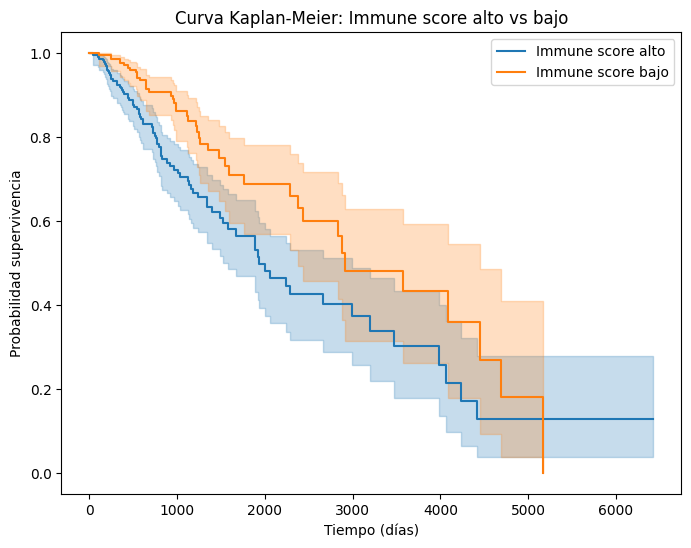

P-valor test log-rank (immune score): 0.0013


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Definir grupos high y low según mediana es común
median_immune = scores_sub['immune_score'].median()
high_immune = scores_sub['immune_score'] >= median_immune

# Supervivencia Kaplan-Meier para high vs low immune
kmf = KaplanMeierFitter()
T = clin_sub['overall_survival']  # Tiempo supervivencia (ej: días)
E = clin_sub['status']  # Evento (1 muerto, 0 censurado)

plt.figure(figsize=(8,6))
kmf.fit(T[high_immune], event_observed=E[high_immune], label='Immune score alto')
ax = kmf.plot_survival_function()
kmf.fit(T[~high_immune], event_observed=E[~high_immune], label='Immune score bajo')
kmf.plot_survival_function(ax=ax)
plt.title('Curva Kaplan-Meier: Immune score alto vs bajo')
plt.xlabel('Tiempo (días)')
plt.ylabel('Probabilidad supervivencia')
plt.show()

# Test log-rank para comparar grupos
result_logrank = logrank_test(T[high_immune], T[~high_immune], event_observed_A=E[high_immune], event_observed_B=E[~high_immune])
print(f"P-valor test log-rank (immune score): {result_logrank.p_value:.4f}")


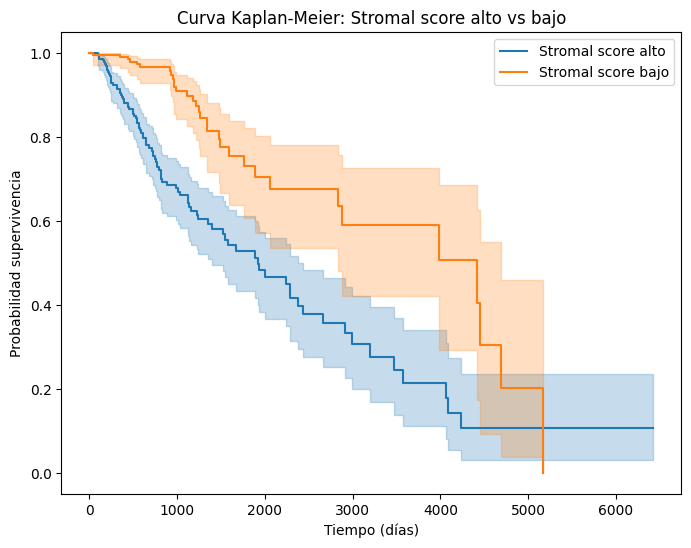

P-valor test log-rank (stromal score): 0.0000


In [22]:
# Definir grupos high y low según mediana es común
median_stromal = scores_sub['stromal_score'].median()
high_stromal = scores_sub['stromal_score'] >= median_stromal

plt.figure(figsize=(8,6))
kmf.fit(T[high_stromal], event_observed=E[high_stromal], label='Stromal score alto')
ax = kmf.plot_survival_function()
kmf.fit(T[~high_stromal], event_observed=E[~high_stromal], label='Stromal score bajo')
kmf.plot_survival_function(ax=ax)
plt.title('Curva Kaplan-Meier: Stromal score alto vs bajo')
plt.xlabel('Tiempo (días)')
plt.ylabel('Probabilidad supervivencia')
plt.show()

# Test log-rank para comparar grupos
result_logrank = logrank_test(T[high_stromal], T[~high_stromal], event_observed_A=E[high_stromal], event_observed_B=E[~high_stromal])
print(f"P-valor test log-rank (stromal score): {result_logrank.p_value:.4f}")

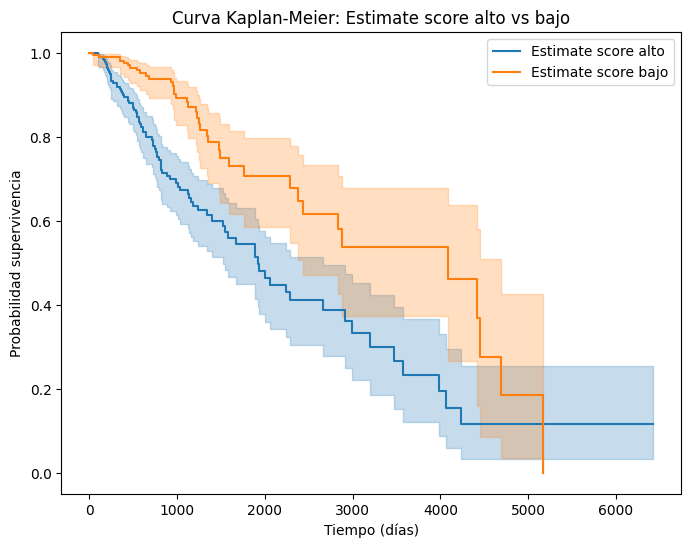

P-valor test log-rank (estimate score): 0.0000


In [23]:
# Definir grupos high y low según mediana es común
median_estimate = scores_sub['estimate_score'].median()
high_estimate = scores_sub['estimate_score'] >= median_estimate

plt.figure(figsize=(8,6))
kmf.fit(T[high_estimate], event_observed=E[high_estimate], label='Estimate score alto')
ax = kmf.plot_survival_function()
kmf.fit(T[~high_estimate], event_observed=E[~high_estimate], label='Estimate score bajo')
kmf.plot_survival_function(ax=ax)
plt.title('Curva Kaplan-Meier: Estimate score alto vs bajo')
plt.xlabel('Tiempo (días)')
plt.ylabel('Probabilidad supervivencia')
plt.show()

# Test log-rank para comparar grupos
result_logrank = logrank_test(T[high_estimate], T[~high_estimate], event_observed_A=E[high_estimate], event_observed_B=E[~high_estimate])
print(f"P-valor test log-rank (estimate score): {result_logrank.p_value:.4f}")

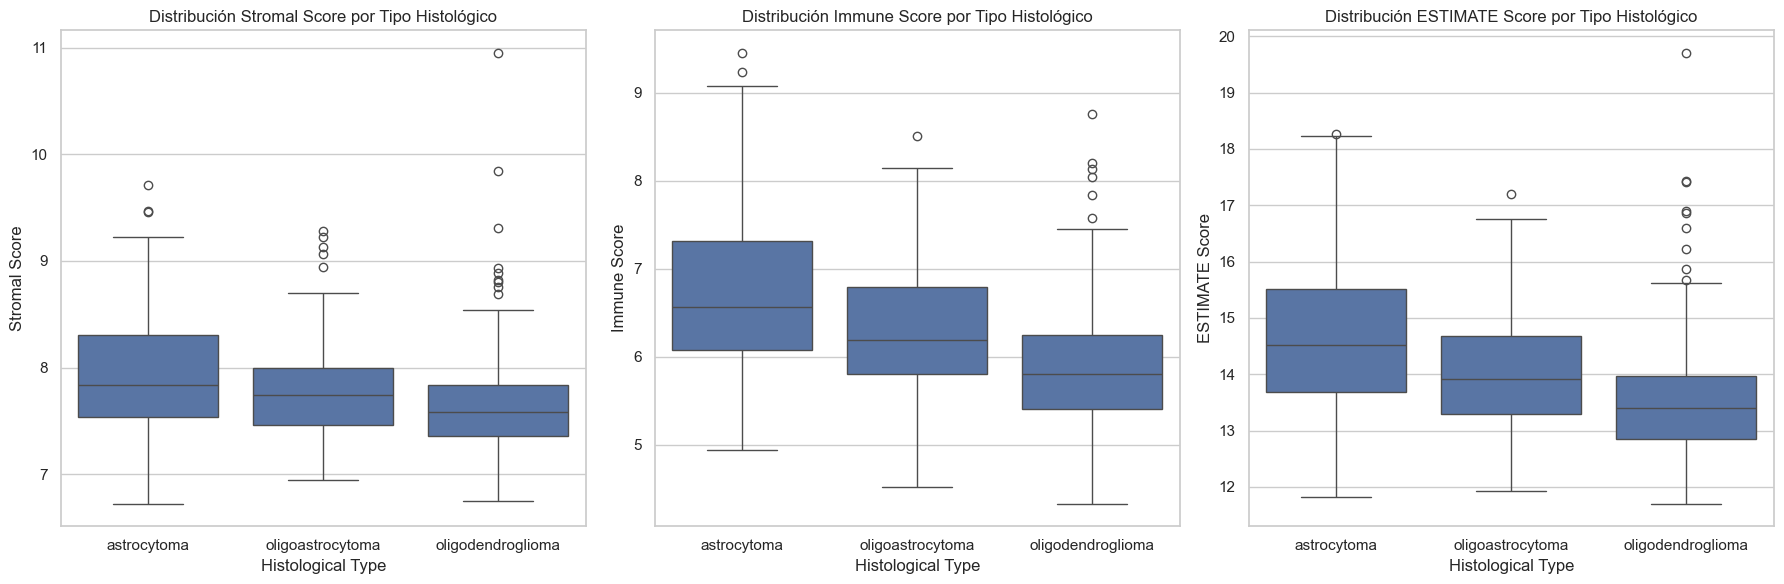

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

data = scores_sub.join(clin['histological_type'])
data = data.dropna(subset=['stromal_score', 'immune_score', 'estimate_score', 'histological_type'])

# Configurar estilo
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Boxplot para Stromal Score
sns.boxplot(x='histological_type', y='stromal_score', data=data, ax=axes[0])
axes[0].set_title('Distribución Stromal Score por Tipo Histológico')
axes[0].set_xlabel('Histological Type')
axes[0].set_ylabel('Stromal Score')

# Boxplot para Immune Score
sns.boxplot(x='histological_type', y='immune_score', data=data, ax=axes[1])
axes[1].set_title('Distribución Immune Score por Tipo Histológico')
axes[1].set_xlabel('Histological Type')
axes[1].set_ylabel('Immune Score')

# Boxplot para ESTIMATE Score
sns.boxplot(x='histological_type', y='estimate_score', data=data,
ax=axes[2])
axes[2].set_title('Distribución ESTIMATE Score por Tipo Histológico')
axes[2].set_xlabel('Histological Type')
axes[2].set_ylabel('ESTIMATE Score')

plt.tight_layout()
plt.show()

## Identificación de genes diferencialmente expresados (DEGs)

La identificación de genes diferencialemente expresados entre grupos alto y bajo puntajes immune y stromal mediante los siguientes criterios:
- $|\log_2(\text{FC})| > 1$ (Fold Change)
- FDR (False Discovery Rate) < 0.05

Son intersectadas las listas de DEGs comunes a ambos puntajes.

In [25]:
scores_sub.head()

,immune_score,stromal_score,estimate_score
TCGA.CS.6665,7.928820,8.307347,16.236166
TCGA.CS.6670,5.218867,7.616709,12.835575
TCGA.DB.A4XC,6.620606,7.846267,14.466873
TCGA.DH.5141,5.894965,7.715391,13.610356
TCGA.DH.A66B,7.272471,7.539039,14.811510


In [26]:
from scipy.stats import ttest_ind

common_samples = expr.columns.intersection(scores_sub.index)

# Subconjunto las muestras comunes para ambos datasets
expr_common = expr.loc[:, common_samples]
scores_sub_common = scores_sub.loc[common_samples]

scores_names = ['immune_score', 'stromal_score', 'estimate_score']

# Diccionarios para guardar resultados por score
deg_results = {}

for score_name in scores_names:
    print(f"Procesando DEGs para {score_name} ...")
    median_score = scores_sub_common[score_name].median()
    
    # Definir grupos alto y bajo para ese score
    high_group = scores_sub_common[score_name] >= median_score
    low_group = ~high_group
    
    # Seleccionar expresión para grupos alto/bajo (los genes están en filas)
    expr_high = expr_common.loc[:, high_group.index[high_group]].copy()
    expr_low = expr_common.loc[:, low_group.index[low_group]].copy()
    
    # Vectores para p-values y logFC
    pvals = []
    logFC = []
    genes = expr_common.index
    
    # Calcular t-test y fc para cada gen
    for gene in genes:
        group1 = expr_high.loc[gene].values
        group2 = expr_low.loc[gene].values
        
        # t-test con varianza desigual (Welch)
        stat, p = ttest_ind(group1, group2, equal_var=False)
        pvals.append(p)
        
        # Fold change promedio (diferencia de medias)
        fc = group1.mean() - group2.mean()  # log2 fold change si expresión es log2-transformada
        logFC.append(fc)
        
    # Crear DataFrame con resultados
    deg_df = pd.DataFrame({
        'gene': genes,
        'logFC': logFC,
        'p_value': pvals
    })
    
    # Corrección Bonferroni (ajuste simple)
    deg_df['adj_p_value'] = deg_df['p_value'] * len(deg_df)
    deg_df['adj_p_value'] = deg_df['adj_p_value'].clip(upper=1)  # corregir valores >1
    
    # Filtrar DEGs significativos: |logFC| > 1 y adj_p_value < 0.05
    deg_sig = deg_df[(deg_df['adj_p_value'] < 0.05) & (deg_df['logFC'].abs() > 1)].copy()
    deg_sig = deg_sig.sort_values('adj_p_value')
    
    # Guardar resultados
    deg_results[score_name] = {
        'all': deg_df,
        'significant': deg_sig
    }
    
    print(f"Score {score_name}: genes diferencialmente expresados significativos = {len(deg_sig)}")
    print(deg_sig.head(), '\n')

Procesando DEGs para immune_score ...
Score immune_score: genes diferencialmente expresados significativos = 1237
          gene     logFC       p_value   adj_p_value
7828   HLA-DRA  2.540546  3.579583e-91  7.189951e-87
3336      CD74  2.255857  9.008415e-91  1.809430e-86
7819   HLA-DOA  2.550684  6.808441e-87  1.367543e-82
7821  HLA-DPA1  2.396949  1.197575e-84  2.405449e-80
7817   HLA-DMA  1.883692  1.951171e-83  3.919121e-79 

Procesando DEGs para stromal_score ...
Score stromal_score: genes diferencialmente expresados significativos = 855
          gene     logFC       p_value   adj_p_value
8544     ITGA5  1.440245  5.886141e-59  1.182290e-54
5849   FAM129A  1.695183  8.655097e-53  1.738463e-48
4006    COL1A2  1.810255  1.901203e-51  3.818757e-47
3602       CFH  1.461562  5.773508e-50  1.159667e-45
11350     MYOF  1.405933  1.320486e-49  2.652328e-45 

Procesando DEGs para estimate_score ...
Score estimate_score: genes diferencialmente expresados significativos = 1248
          gen

## Análisis funcional y enriquecimiento

Análisis de enriquecimiento funcional con:
- Gene Ontology: procesos biológicos, funciones moleculares y componentes celulares.
- KEGG: rutas metaólicas y de señalización.

In [27]:
import gseapy as gp

# Preparar lista de genes up-regulados y down-regulados
genes_up = deg_sig[deg_sig['logFC'] > 1]['gene'].tolist()
genes_down = deg_sig[deg_sig['logFC'] < -1]['gene'].tolist()

# Enriquecimiento KEGG por ejemplo para genes up
enr_up = gp.enrichr(
    gene_list=genes_up,
    gene_sets=['KEGG_2021_Human'],
    organism='Human',
    outdir=None,  # no genera archivos
    cutoff=0.05
)
print("Enriquecimiento KEGG - genes UP regulados (top 5):")
print(enr_up.results.head())


Enriquecimiento KEGG - genes UP regulados (top 5):
          Gene_set                             Term Overlap       P-value  \
0  KEGG_2021_Human  Staphylococcus aureus infection   42/95  5.505934e-29   
1  KEGG_2021_Human                        Phagosome  49/152  4.342931e-26   
2  KEGG_2021_Human       Osteoclast differentiation  43/127  5.113150e-24   
3  KEGG_2021_Human       Hematopoietic cell lineage   37/99  1.410812e-22   
4  KEGG_2021_Human                    Leishmaniasis   33/77  1.597991e-22   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0      1.486602e-26            0                     0   15.076535   
1      5.862957e-24            0                     0    9.090890   
2      4.601835e-22            0                     0    9.732892   
3      8.629153e-21            0                     0   11.291517   
4      8.629153e-21            0                     0   14.147557   

   Combined Score                                              Ge

In [28]:
print(genes_up)

['HLA-DRA', 'CD74', 'HLA-DPA1', 'HLA-DOA', 'HLA-DPB1', 'HLA-DRB1', 'HLA-DMA', 'PLBD1', 'CASP4', 'SP100', 'CIITA', 'ADPRH', 'KYNU', 'SERPINA1', 'SQRDL', 'MSR1', 'HLA-DMB', 'HLA-E', 'CCR5', 'HLA-DQA1', 'S100A4', 'RAC2', 'FAM129A', 'S100A11', 'GPR65', 'CLIC1', 'PTGER4', 'IL2RG', 'GBP5', 'TRIM38', 'FGL2', 'CTSC', 'APOBEC3G', 'FCGR2A', 'CASP8', 'IFI30', 'DENND2D', 'ARHGAP15', 'LTBR', 'TNFAIP8', 'CECR1', 'CTSS', 'PLSCR1', 'MSN', 'FCGR2C', 'ELF4', 'CASP1', 'ITGAL', 'CD7', 'CCL5', 'MYOF', 'ARHGAP25', 'SP140L', 'HLA-DRB5', 'CD3E', 'CD2', 'PDCD1LG2', 'FBP1', 'SLC15A3', 'CHI3L2', 'PTPRC', 'CTSZ', 'LYN', 'MX2', 'LAIR1', 'RAB32', 'CARD16', 'FCGR3A', 'SERPINB1', 'ARHGDIB', 'PTPN7', 'MYL12A', 'TLR8', 'CSF2RB', 'TYMP', 'DAPP1', 'MYO1F', 'CYTIP', 'CD69', 'B2M', 'C16orf54', 'TGFBR2', 'APOBEC3C', 'ANXA2P2', 'HLA-B', 'ITGB2', 'RBM47', 'EPSTI1', 'GAPT', 'TRAF3IP3', 'LRRC25', 'LY96', 'GBP1', 'ARPC1B', 'OLFML3', 'SLAMF6', 'LCP2', 'C1R', 'RHOH', 'ITGA5', 'EMR1', 'TNFRSF1B', 'PLCG2', 'SPINT1', 'SERPING1', 'TYR

In [29]:
# Enriquecimiento GO para genes up regulados (BP, CC, MF)
enr_go_bp_up = gp.enrichr(
    gene_list=genes_up,
    gene_sets=['GO_Biological_Process_2025'],
    organism='Human',
    outdir=None,
    cutoff=0.05
)
print("Enriquecimiento GO BP - genes UP regulados (top 5):")
print(enr_go_bp_up.results.head())

enr_go_cc_up = gp.enrichr(
    gene_list=genes_up,
    gene_sets=['GO_Cellular_Component_2025'],
    organism='Human',
    outdir=None,
    cutoff=0.05
)
print("Enriquecimiento GO CC - genes UP regulados (top 5):")
print(enr_go_cc_up.results.head())

enr_go_mf_up = gp.enrichr(
    gene_list=genes_up,
    gene_sets=['GO_Molecular_Function_2025'],
    organism='Human',
    outdir=None,
    cutoff=0.05
)
print("Enriquecimiento GO MF - genes UP regulados (top 5):")
print(enr_go_mf_up.results.head())

Enriquecimiento GO BP - genes UP regulados (top 5):
                     Gene_set  \
0  GO_Biological_Process_2025   
1  GO_Biological_Process_2025   
2  GO_Biological_Process_2025   
3  GO_Biological_Process_2025   
4  GO_Biological_Process_2025   

                                                Term Overlap       P-value  \
0                 Inflammatory Response (GO:0006954)  76/261  2.014922e-36   
1  Positive Regulation of Cytokine Production (GO...  82/325  3.215103e-34   
2   Cytokine-Mediated Signaling Pathway (GO:0019221)  64/255  9.053124e-27   
3    Regulation of T Cell Proliferation (GO:0042129)   36/83  1.133883e-24   
4  Regulation of Tumor Necrosis Factor Production...  44/131  2.204612e-24   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0      6.344990e-33            0                     0    8.036059   
1      5.062180e-31            0                     0    6.621986   
2      9.502763e-24            0                     0    6.471635   


## Red de interacción proteica (PPI) y selección de genes hub 

Se construye una red PPI con datos STRING (interacciones con score mayor a 0.9). Son identificados 25 genes hub con mayor centralidad evaluando según el grado de cada gen en la red. Estos genes están asociados a procesos inmunes claves. 

In [30]:
import requests

def chunk_list(lst, n):
    """Divide una lista en sublistas de tamaño máximo n."""
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

def get_string_edges(genes, species=9606, min_score=900, batch_size=50):
    """
    Consulta a la API STRING para obtener interacciones
    genes: lista de genes (símbolos)
    species: 9606 para humano
    min_score: umbral mínimo de confiabilidad (900 = 0.9)
    batch_size: cantidad máxima de genes por llamada
    Retorna lista de tuplas (protein1, protein2)
    """
    all_edges = []
    genes_upper = set(g.upper() for g in genes)

    for batch in chunk_list(genes, batch_size):
        genes_str = "%0d".join(batch)
        url = f"https://string-db.org/api/tsv/network?identifiers={genes_str}&species={species}&required_score={min_score}"
        response = requests.get(url)

        if response.ok:
            lines = response.text.strip().split('\n')
            # Saltar cabezera
            for line in lines[1:]:
                fields = line.split('\t')
                protein1 = fields[2].upper()
                protein2 = fields[3].upper()
                if protein1 in genes_upper and protein2 in genes_upper:
                    all_edges.append((protein1, protein2))
        else:
            print(f"Error al consultar STRING API para batch {batch[0]}-{batch[-1]}: Código {response.status_code}")

    return all_edges

# Ejemplo: usar genes up regulados para obtener aristas
edges_up = get_string_edges(genes_up, batch_size=50)

print(f"Aristas (interacciones) obtenidas para genes up: {len(edges_up)}")
print("Primeras 10 aristas:")
print(edges_up[:10])


Aristas (interacciones) obtenidas para genes up: 121
Primeras 10 aristas:
[('CD74', 'HLA-DOA'), ('CD74', 'CTSS'), ('CD74', 'HLA-DPB1'), ('CD74', 'HLA-DMB'), ('CD74', 'HLA-DPA1'), ('CD74', 'HLA-DMA'), ('CD74', 'HLA-DQA1'), ('CD74', 'HLA-DRB1'), ('CD74', 'HLA-DRA'), ('HLA-DOA', 'HLA-DRB1')]


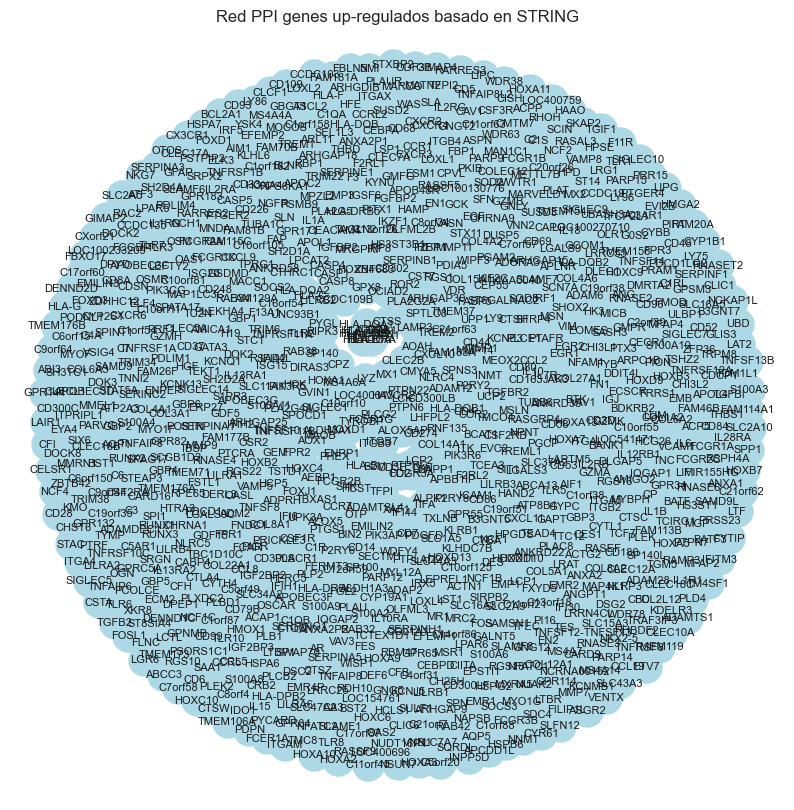

In [31]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_nodes_from(genes_up)
G.add_edges_from(edges_up)

plt.figure(figsize=(10,10))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("Red PPI genes up-regulados basado en STRING")
plt.axis('off')
plt.show()


In [32]:
degree_dict = dict(G.degree)
# Ordenar genes por grado descendente
hub_genes_sorted = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)
top_hubs = [gene for gene, deg in hub_genes_sorted[:100]]  # por ejemplo, top 100

print(f"Top {len(top_hubs)} genes hub seleccionados: {top_hubs}")


Top 100 genes hub seleccionados: ['CD74', 'HLA-DPB1', 'HLA-DRB1', 'HLA-DMA', 'HLA-DMB', 'HLA-DRA', 'HLA-DPA1', 'HLA-DOA', 'HLA-E', 'HLA-DQA1', 'PTPRC', 'LYN', 'IL10', 'CD3E', 'FCGR3A', 'LCK', 'CASP1', 'CD2', 'B2M', 'LCP2', 'SERPING1', 'CD4', 'FCER1G', 'C1QB', 'C1QC', 'RUNX1', 'HLA-C', 'SYK', 'TIMP1', 'CD44', 'MMP14', 'IL7R', 'COL1A2', 'ISG15', 'IFI44L', 'RSAD2', 'MAOB', 'CASP4', 'CCR5', 'CASP8', 'CTSS', 'CCL5', 'DAPP1', 'HLA-B', 'ITGB2', 'ITGA5', 'PLCG2', 'TYROBP', 'ALOX5', 'LSP1', 'GZMA', 'HLA-DQB1', 'CCR2', 'CYBA', 'NCF1', 'CLEC7A', 'PTGS1', 'RIPK3', 'IL2RB', 'PYGL', 'CD53', 'RUNX3', 'GZMK', 'LAPTM5', 'SPI1', 'ICAM1', 'CD3D', 'CD86', 'HAVCR2', 'ALPK1', 'PTPN22', 'TIFA', 'CXCR3', 'PTPN6', 'CCR1', 'C1S', 'C2', 'HCK', 'VAV1', 'ITGB3', 'PIK3R5', 'HLA-DQA2', 'RNASE2', 'BTK', 'ITGB7', 'LILRB2', 'ANG', 'HCST', 'FCGR2B', 'PIK3R6', 'ITK', 'TLR7', 'PRF1', 'GZMH', 'TLR3', 'IFIH1', 'HERC5', 'COL1A1', 'CD80', 'CD163']


In [33]:
clin.head()

attrib_name,years_to_birth,Tumor_purity,histological_type,gender,radiation_therapy,race,ethnicity,overall_survival,status
TCGA.CS.6665,51.0,0.6573,astrocytoma,female,yes,white,nothispanicorlatino,1568.0,False
TCGA.CS.6670,43.0,0.9816,oligodendroglioma,male,NaN,white,nothispanicorlatino,1426.0,False
TCGA.DB.A4XC,26.0,0.8892,oligoastrocytoma,male,yes,white,nothispanicorlatino,1421.0,False
TCGA.DH.5141,32.0,0.9387,oligodendroglioma,male,yes,white,hispanicorlatino,968.0,False
TCGA.DH.A66B,52.0,0.8806,astrocytoma,male,yes,white,nothispanicorlatino,1279.0,False


In [34]:
clin.info()

<class 'pandas.core.frame.DataFrame'>
Index: 481 entries, TCGA.CS.6665 to TCGA.WY.A85E
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   years_to_birth     480 non-null    float64 
 1   Tumor_purity       481 non-null    float64 
 2   histological_type  481 non-null    category
 3   gender             481 non-null    category
 4   radiation_therapy  465 non-null    category
 5   race               472 non-null    category
 6   ethnicity          450 non-null    category
 7   overall_survival   481 non-null    float64 
 8   status             481 non-null    bool    
dtypes: bool(1), category(5), float64(3)
memory usage: 34.7+ KB


In [35]:
expr.T.head()

attrib_name,A1BG,A1CF,A2BP1,A2LD1,A2ML1,A2M,A4GALT,A4GNT,AAA1,AAAS,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,tAKR
TCGA.CS.4938,6.5715,0.0,4.5641,3.8564,7.1997,13.8518,6.2176,0.0000,0.0,9.1944,...,6.0266,9.0339,10.3581,0.0000,10.5476,10.6438,10.1957,9.7094,9.6052,0.0
TCGA.CS.4941,6.1944,0.0,9.0375,7.1808,9.0290,14.1314,7.3288,1.0252,0.0,8.4955,...,6.7406,8.8721,10.2618,0.4277,10.7750,11.9259,10.7387,9.9894,4.3204,0.0
TCGA.CS.4942,6.2375,0.0,8.5295,5.7117,7.4545,14.2341,5.5011,0.4287,0.0,9.1342,...,6.8608,8.8308,10.1078,0.4287,10.6322,11.1134,10.4766,9.4674,10.7374,0.0
TCGA.CS.4943,4.9535,0.0,5.5235,3.9052,7.4920,13.5168,5.1915,1.2043,0.0,10.2793,...,6.4921,8.9427,10.3324,2.0911,10.7823,11.0584,10.9054,9.4311,8.0716,0.0
TCGA.CS.4944,4.6844,0.0,6.7335,4.2491,7.3253,13.4115,6.8579,0.5892,0.0,9.0637,...,5.4385,8.3434,9.9855,0.5892,10.2598,10.7259,9.5133,8.8390,4.3694,0.0


## Modelo de Riesgo Lineal basado en genes hub 

Teniendo en cuenta la regresión de Cox multivariada se obtienen coeficientes $\beta_i$ para cada gen hub. Calculando entonces el score de riesgo (RS): 

$$
RS = \sum_{i=1}^{25} \beta_i \times \text{Exp}_i
$$

Los pacientes se estratifican en riesgo alto o bajo según la mediana de RS.

In [36]:
from lifelines import CoxPHFitter, KaplanMeierFitter

# Preparamos DataFrame de expresión transpuesta: muestras filas, genes columnas
expr_T = expr.loc[top_hubs].T

common_samples = expr_T.index.intersection(clin.index)
print(f"Cantidad de muestras comunes: {len(common_samples)}")

expr_T_sub = expr_T.loc[common_samples]
clin_sub = clin.loc[common_samples]

data_cox = expr_T.join(clin_sub[['overall_survival', 'status']])

# Eliminar muestras con datos faltantes
data_cox = data_cox.dropna()

cph = CoxPHFitter()
cph.fit(data_cox, duration_col='overall_survival', event_col='status')
cph.summary.style.format("{:.4f}")

Cantidad de muestras comunes: 481


d:\Coding\investigacionIA\entorno\Lib\site-packages\lifelines\utils\__init__.py:1185: UserWarning: Attempting to convert an unexpected datatype 'object' to float. Suggestion: 1) use `lifelines.utils.datetimes_to_durations` to do conversions or 2) manually convert to floats/booleans.
  warnings.warn(warning_text, UserWarning)


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
CD74,1.8387,6.2881,0.7687,0.3321,3.3452,1.3939,28.3666,0.0000,2.3920,0.0168,5.8991
HLA-DPB1,-0.4230,0.6551,0.5878,-1.5750,0.7291,0.2070,2.0731,0.0000,-0.7196,0.4718,1.0839
HLA-DRB1,-1.1636,0.3124,0.3974,-1.9424,-0.3848,0.1434,0.6806,0.0000,-2.9283,0.0034,8.1969
HLA-DMA,-0.8998,0.4067,0.7126,-2.2964,0.4969,0.1006,1.6436,0.0000,-1.2627,0.2067,2.2744
HLA-DMB,1.7997,6.0477,0.7239,0.3809,3.2184,1.4636,24.9884,0.0000,2.4862,0.0129,6.2753
HLA-DRA,-1.3595,0.2568,0.7814,-2.8909,0.1720,0.0555,1.1876,0.0000,-1.7399,0.0819,3.6104
HLA-DPA1,1.2168,3.3763,0.5340,0.1703,2.2633,1.1856,9.6149,0.0000,2.2788,0.0227,5.4627
HLA-DOA,-0.0806,0.9226,0.5486,-1.1558,0.9946,0.3148,2.7037,0.0000,-0.1469,0.8832,0.1792
HLA-E,0.1788,1.1958,0.6696,-1.1336,1.4912,0.3219,4.4423,0.0000,0.2670,0.7894,0.3411


d:\Coding\investigacionIA\entorno\Lib\site-packages\lifelines\utils\__init__.py:1185: UserWarning: Attempting to convert an unexpected datatype 'object' to float. Suggestion: 1) use `lifelines.utils.datetimes_to_durations` to do conversions or 2) manually convert to floats/booleans.
  warnings.warn(warning_text, UserWarning)
d:\Coding\investigacionIA\entorno\Lib\site-packages\lifelines\utils\__init__.py:1185: UserWarning: Attempting to convert an unexpected datatype 'object' to float. Suggestion: 1) use `lifelines.utils.datetimes_to_durations` to do conversions or 2) manually convert to floats/booleans.
  warnings.warn(warning_text, UserWarning)


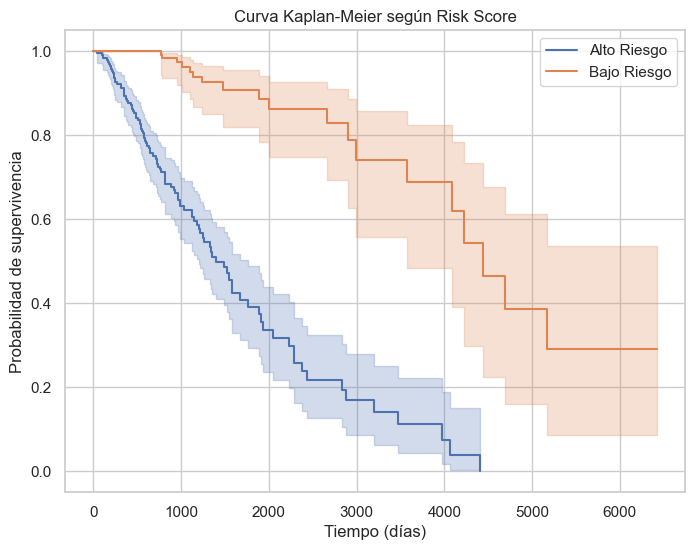

In [37]:
# Calcular risk score: suma ponderada coef * expresión
beta = cph.params_
risk_score = data_cox[top_hubs].dot(beta)

data_cox['risk_score'] = risk_score

# Dividir en grupos risk alto y bajo según mediana
median_rs = risk_score.median()
high_risk = risk_score >= median_rs

# Visualizar curvas Kaplan-Meier para riesgo alto y bajo
kmf = KaplanMeierFitter()
plt.figure(figsize=(8,6))

kmf.fit(data_cox.loc[high_risk, 'overall_survival'], event_observed=data_cox.loc[high_risk, 'status'], label='Alto Riesgo')
ax = kmf.plot_survival_function()

kmf.fit(data_cox.loc[~high_risk, 'overall_survival'], event_observed=data_cox.loc[~high_risk, 'status'], label='Bajo Riesgo')
kmf.plot_survival_function(ax=ax)

plt.title('Curva Kaplan-Meier según Risk Score')
plt.xlabel('Tiempo (días)')
plt.ylabel('Probabilidad de supervivencia')
plt.show()


In [38]:
# Test log-rank para diferencia estadística
result_logrank = logrank_test(
    data_cox.loc[high_risk, 'overall_survival'], data_cox.loc[~high_risk, 'overall_survival'],
    event_observed_A=data_cox.loc[high_risk, 'status'], event_observed_B=data_cox.loc[~high_risk, 'status']
)
print(f"P-valor test log-rank grupos RS: {result_logrank.p_value:.4e}")

P-valor test log-rank grupos RS: 9.9590e-23


In [39]:
# Definir supervivencia binaria a 3 años (1095 días)
data_cox['survival_3yr'] = (data_cox['overall_survival'] >= 1095).astype(int)

# Calcular AUC ROC para predecir supervivencia a 3 años usando risk_score
auc_rs = roc_auc_score(data_cox['survival_3yr'], -data_cox['risk_score']) 
# Negamos el risk_score porque un score alto indica peor pronóstico (menos supervivencia)
print(f"AUC ROC modelo Risk Score para supervivencia a 3 años: {auc_rs:.4f}")

AUC ROC modelo Risk Score para supervivencia a 3 años: 0.5743


In [40]:
data_cox.head()

attrib_name,CD74,HLA-DPB1,HLA-DRB1,HLA-DMA,HLA-DMB,HLA-DRA,HLA-DPA1,HLA-DOA,HLA-E,HLA-DQA1,...,TLR3,IFIH1,HERC5,COL1A1,CD80,CD163,overall_survival,status,risk_score,survival_3yr
TCGA.CS.4938,12.5668,8.6102,8.7590,8.5993,8.9834,10.7880,8.8908,6.8782,12.2597,6.8204,...,6.0359,7.7536,9.1736,5.7512,0.5055,6.8627,3574.0,False,-7.832610,1
TCGA.CS.4941,15.4927,11.9222,12.3668,10.5364,10.8081,13.9021,12.5162,10.0694,13.9244,10.2799,...,8.3274,10.1575,10.4911,8.4117,3.8538,9.7537,234.0,True,-2.580570,0
TCGA.CS.4942,15.3739,11.4483,12.7477,10.5580,10.8706,13.7942,11.9650,10.3466,13.7275,10.4735,...,9.0234,9.1324,9.3929,5.8167,2.9856,8.9766,1335.0,True,-3.892725,1
TCGA.CS.4943,13.2865,10.4928,9.8587,9.0924,9.5139,11.8657,10.5019,8.5010,11.6388,8.4154,...,5.8916,7.0874,6.7673,8.6443,1.7148,8.7332,1106.0,True,-6.731689,1
TCGA.CS.4944,14.4549,11.6700,11.6364,10.3967,9.8603,13.2601,11.5003,9.0541,12.5336,9.8875,...,6.3961,7.6706,8.1443,4.6267,0.0000,9.8959,1828.0,False,-4.565826,1


In [41]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Suponiendo que clin_sub y data_cox ya están definidos, y ambos tienen el mismo índice y número de filas

# 1. Codifica histological_type en clin_sub
encoder = OneHotEncoder(sparse_output=False) 
encoded_cols = encoder.fit_transform(clin_sub[['histological_type']])

# Verifica las categorías codificadas
print("Categorías detectadas:", encoder.categories_)

# 2. Convierte el array en DataFrame y conserva el índice original
encoded_df = pd.DataFrame(
    encoded_cols, 
    columns=encoder.get_feature_names_out(['histological_type']), 
    index=clin_sub.index
)

# 3. Une las columnas codificadas a data_cox
data_cox = pd.concat([data_cox, encoded_df], axis=1)

# 4. Guarda el DataFrame en el archivo deseado
data_cox.to_csv('../data/data_cox_with_survival3yr_ht.csv', index=True)

print("Archivo CSV guardado en '../data/data_cox_with_survival3yr_ht.csv'")


Categorías detectadas: [array(['astrocytoma', 'oligoastrocytoma', 'oligodendroglioma'],
      dtype=object)]
Archivo CSV guardado en '../data/data_cox_with_survival3yr_ht.csv'


In [42]:
data_cox.head()

,CD74,HLA-DPB1,HLA-DRB1,HLA-DMA,HLA-DMB,HLA-DRA,HLA-DPA1,HLA-DOA,HLA-E,HLA-DQA1,...,COL1A1,CD80,CD163,overall_survival,status,risk_score,survival_3yr,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma
TCGA.CS.4938,12.5668,8.6102,8.7590,8.5993,8.9834,10.7880,8.8908,6.8782,12.2597,6.8204,...,5.7512,0.5055,6.8627,3574.0,False,-7.832610,1,1.0,0.0,0.0
TCGA.CS.4941,15.4927,11.9222,12.3668,10.5364,10.8081,13.9021,12.5162,10.0694,13.9244,10.2799,...,8.4117,3.8538,9.7537,234.0,True,-2.580570,0,1.0,0.0,0.0
TCGA.CS.4942,15.3739,11.4483,12.7477,10.5580,10.8706,13.7942,11.9650,10.3466,13.7275,10.4735,...,5.8167,2.9856,8.9766,1335.0,True,-3.892725,1,1.0,0.0,0.0
TCGA.CS.4943,13.2865,10.4928,9.8587,9.0924,9.5139,11.8657,10.5019,8.5010,11.6388,8.4154,...,8.6443,1.7148,8.7332,1106.0,True,-6.731689,1,1.0,0.0,0.0
TCGA.CS.4944,14.4549,11.6700,11.6364,10.3967,9.8603,13.2601,11.5003,9.0541,12.5336,9.8875,...,4.6267,0.0000,9.8959,1828.0,False,-4.565826,1,1.0,0.0,0.0


In [43]:
data_cox.info()

<class 'pandas.core.frame.DataFrame'>
Index: 481 entries, TCGA.CS.4938 to TCGA.WY.A85E
Columns: 107 entries, CD74 to histological_type_oligodendroglioma
dtypes: float64(105), int64(1), object(1)
memory usage: 422.0+ KB


In [44]:
# Elimina la columna original si existe
if 'histological_type' in data_cox.columns:
    data_cox = data_cox.drop('histological_type', axis=1)

# Elimina todas las columnas codificadas de tipos histológicos si existen
hist_cols = [col for col in data_cox.columns if col.startswith('histological_type')]
data_cox = data_cox.drop(hist_cols, axis=1)

# Guarda el DataFrame ya sin NADA de tipos histológicos
data_cox.to_csv('../data/data_cox_with_survival3yr.csv', index=True)

print("Archivo CSV guardado en '../data/data_cox_with_survival3yr.csv' sin los tipos histológicos")


Archivo CSV guardado en '../data/data_cox_with_survival3yr.csv' sin los tipos histológicos
